Saving results to: /Users/BAEK/Code/sim2real-pendulum/sim2real/ch1_modeling/result
geometry check: worst tip position error over 1000 poses = 4.44e-16 m
inertia check: mass matrix diagonal at upright = [0.33333334 0.33333333], I_pivot = 0.33333 kg*m^2
straightness check: azimuth of the outbound path spans 44.85 to 45.00 degrees (leaning toward 45)
growth check: max relative error vs alpha0*cosh(w t) = 0.37%
energy check: range over 5 s = 6.541e-07 J (scale m*g*L = 9.81 J)
gif: 600 frames at 20 fps = 30.0 s


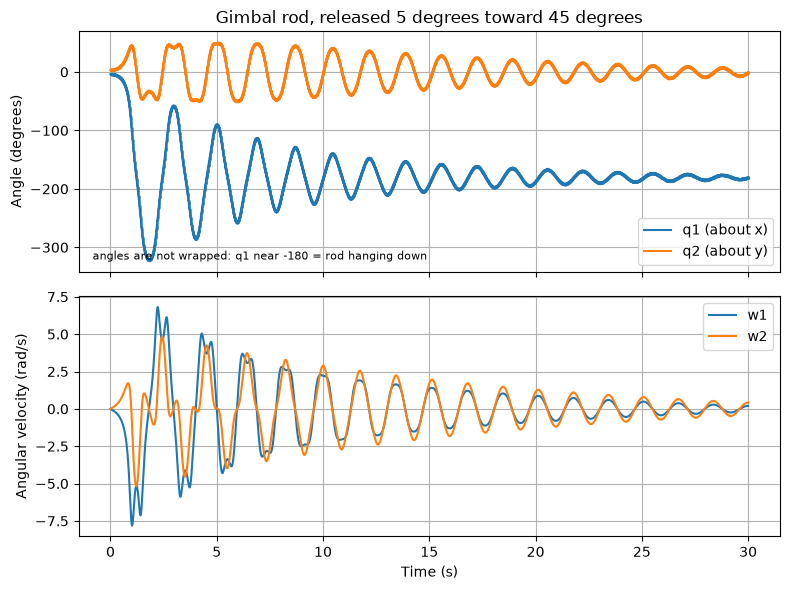

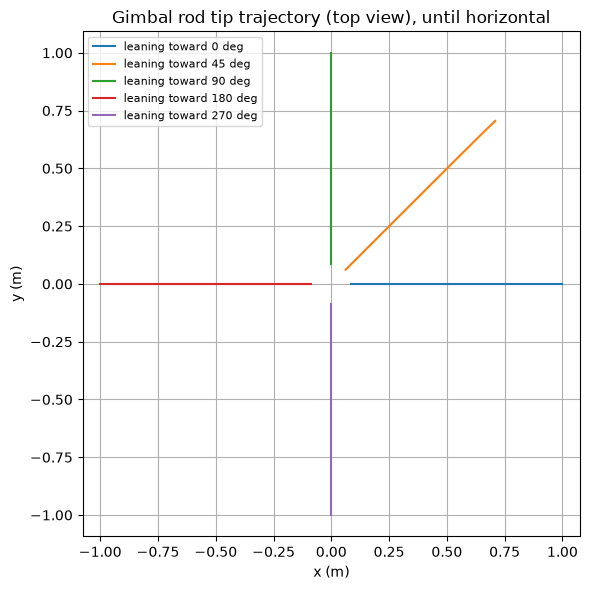

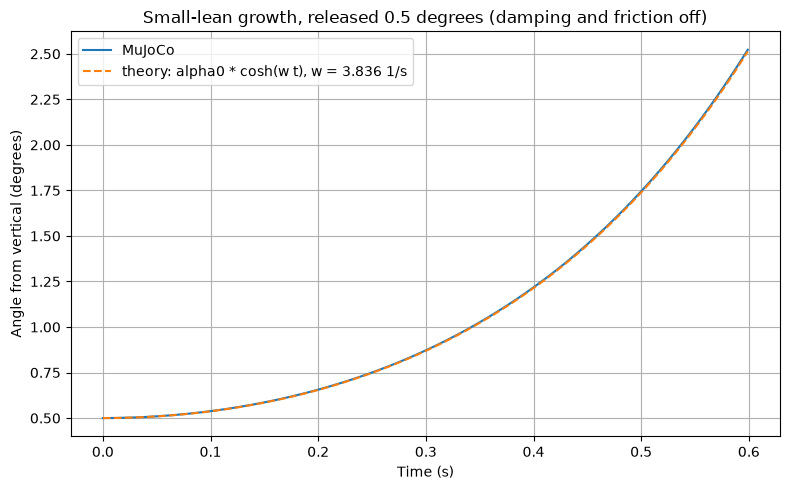

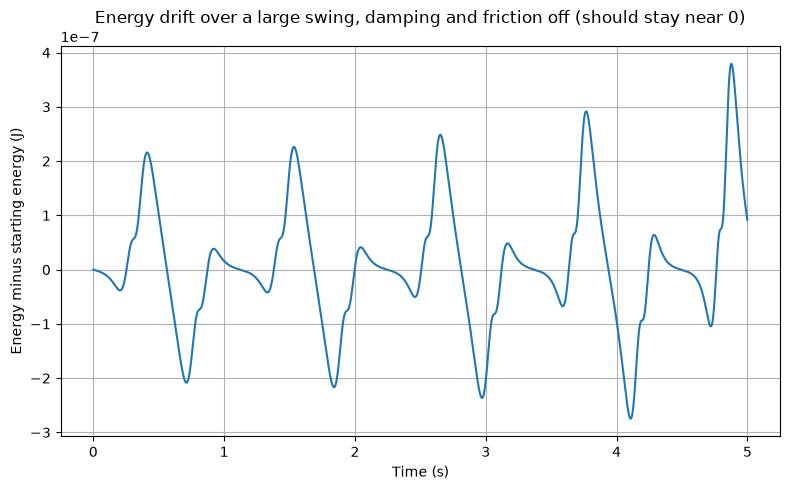

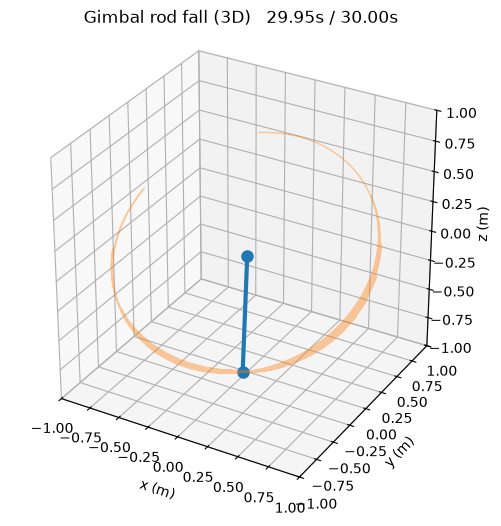

In [ ]:
import os
import mujoco  # type: ignore
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from matplotlib.animation import FuncAnimation, PillowWriter  # type: ignore
from datetime import datetime

NOTEBOOK_DIR = (
    os.getcwd()
)  # the folder the notebook runs from, should be sim2real/ch1_modeling
RESULT_DIR = os.path.join(NOTEBOOK_DIR, "result")
os.makedirs(RESULT_DIR, exist_ok=True)
print("Saving results to:", os.path.abspath(RESULT_DIR))

# ─────────────────────────────────────────────
# STEP 1: Define the gimbal rod as a MuJoCo XML model
#
# This XML describes the STRUCTURE of the system (two hinges in a row, a rod, gravity).
# The structure is FOUNDATIONAL, you are choosing it, MuJoCo does not derive it for you.
#
# ring = a tiny placeholder body between the two hinges (MuJoCo needs some mass on every moving body)
# jx = hinge about the x axis, jy = hinge about the y axis. Two hinges in a row let the rod lean in ANY direction.
# rod points straight UP (+z) when both angles are 0, that is the unstable position.
# inertial = we give the rod's mass properties directly instead of letting MuJoCo infer them from a capsule
# diaginertia = "Ixx Iyy Izz" about the rod's center of mass (kg*m^2), thin rod: m*L^2/12 across the rod, m*r^2/2 about its own axis
# motor_x, motor_y = torque motors on each hinge (N*m), gear=1 means the input IS the torque
# ctrlrange = torque limit of each motor (N*m)
# flag energy = lets MuJoCo report potential and kinetic energy (used in the energy check)
# ─────────────────────────────────────────────

GRAVITY = 9.81  # m/s^2, foundational (measured constant)
TIMESTEP = 0.001  # s, foundational (numerical choice)
ROD_LENGTH = 1.0  # m, foundational (your choice for this experiment)
ROD_MASS = 1.0  # kg, foundational
TORQUE_MAX = 3.0  # N*m, foundational, torque limit of each motor
DAMPING = 0.04  # N*m*s/rad, foundational (real-world value, used by every run except the two physics checks)
FRICTIONLOSS = 0.02  # N*m, foundational (real-world value, used by every run except the two physics checks)

I_COM = ROD_MASS * ROD_LENGTH**2 / 12  # kg*m^2, derived (thin rod about its center)
I_ZZ = 2e-4  # kg*m^2, foundational: rod about its OWN axis, half m r^2 with r = 0.02 m (1e-6 made the gimbal lock stiff, see PLAN.MD F1)
OMEGA_UNSTABLE = np.sqrt(
    1.5 * GRAVITY / ROD_LENGTH
)  # 1/s, derived: growth rate of a small tilt (from I_pivot = m*L^2/3)

xml = f"""
<mujoco>
    <compiler angle="radian"/>
    <option gravity="0 0 -{GRAVITY}" timestep="{TIMESTEP}" integrator="RK4">
        <flag energy="enable"/>
    </option>
    <worldbody>
        <body name="ring" pos="0 0 0">
            <inertial pos="0 0 0" mass="1e-4" diaginertia="1e-8 1e-8 1e-8"/>
            <joint name="jx" type="hinge" axis="1 0 0" damping="{DAMPING}" frictionloss="{FRICTIONLOSS}"/>
            <body name="rod" pos="0 0 0">
                <inertial pos="0 0 {ROD_LENGTH / 2}" mass="{ROD_MASS}" diaginertia="{I_COM} {I_COM} {I_ZZ}"/>
                <joint name="jy" type="hinge" axis="0 1 0" damping="{DAMPING}" frictionloss="{FRICTIONLOSS}"/>
                <geom name="arm" type="capsule" fromto="0 0 0 0 0 {ROD_LENGTH}" size="0.02" contype="0" conaffinity="0" mass="0"/>
                <site name="tip" pos="0 0 {ROD_LENGTH}" size="0.03"/>
            </body>
        </body>
    </worldbody>
    <actuator>
        <motor name="motor_x" joint="jx" gear="1" ctrllimited="true" ctrlrange="-{TORQUE_MAX} {TORQUE_MAX}"/>
        <motor name="motor_y" joint="jy" gear="1" ctrllimited="true" ctrlrange="-{TORQUE_MAX} {TORQUE_MAX}"/>
    </actuator>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(xml)  # blueprint
data = mujoco.MjData(model)  # object
tip_id = model.site("tip").id  # lets us read the tip position every step

# ─────────────────────────────────────────────
# STEP 1b: Checks on the model itself, before any simulation
#
# (a) GEOMETRY: tip position from joint angles, derived by hand (Rx(q1) then Ry(q2) applied to (0, 0, L)):
#         x = L sin(q2),   y = -L sin(q1) cos(q2),   z = L cos(q1) cos(q2)       (DERIVED)
#     We compare with MuJoCo's site position on 1000 random poses.
# (b) INERTIA: at upright the mass matrix should be diagonal with m*L^2/3 = I_pivot (DERIVED), both hinges see
#     the rod rotating about the pivot.
# ─────────────────────────────────────────────

rng = np.random.default_rng(0)
geometry_error = 0.0
for _ in range(1000):
    q1_rand, q2_rand = rng.uniform(-np.pi, np.pi), rng.uniform(-np.pi / 2, np.pi / 2)
    data.qpos[:] = [q1_rand, q2_rand]
    mujoco.mj_forward(model, data)
    tip_formula = ROD_LENGTH * np.array(
        [
            np.sin(q2_rand),
            -np.sin(q1_rand) * np.cos(q2_rand),
            np.cos(q1_rand) * np.cos(q2_rand),
        ]
    )
    geometry_error = max(
        geometry_error, np.abs(data.site_xpos[tip_id] - tip_formula).max()
    )
print(
    f"geometry check: worst tip position error over 1000 poses = {geometry_error:.2e} m"
)
assert (
    geometry_error < 1e-12
), "geometry check failed: tip formula does not match MuJoCo"

data.qpos[:] = 0.0
mujoco.mj_forward(model, data)
mass_matrix = np.zeros((2, 2))
for i in range(2):
    column = np.zeros(2)
    mujoco.mj_mulM(
        model, data, column, np.eye(2)[i]
    )  # column i = M times unit vector i
    mass_matrix[:, i] = column
I_PIVOT = ROD_MASS * ROD_LENGTH**2 / 3  # kg*m^2, derived
print(
    f"inertia check: mass matrix diagonal at upright = {np.diag(mass_matrix)}, I_pivot = {I_PIVOT:.5f} kg*m^2"
)
assert (
    np.allclose(np.diag(mass_matrix), I_PIVOT, rtol=1e-4)
    and abs(mass_matrix[0, 1]) < 1e-9
), "inertia check failed"

# ─────────────────────────────────────────────
# STEP 2: Helper that releases the rod from a lean and runs the simulation
#
# Release the rod from a small lean, motors OFF, so it falls freely.
# The lean is described by how far (tilt, from vertical) and which way (direction,
# 0 = toward +x, 90 = toward +y). These are FOUNDATIONAL choices, not derived.
#
# Converting the lean into the two joint angles (derived by inverting the tip position formula):
#   rod direction  ux = sin(tilt) cos(dir),  uy = sin(tilt) sin(dir)
#   q2 = arcsin(ux),   q1 = arcsin(-uy / cos(q2))
#
# The same helper is used for every run below, so every run uses identical physics.
# ─────────────────────────────────────────────


def run_fall(
    tilt_deg,
    direction_deg,
    n_steps,
    damping=DAMPING,
    frictionloss=FRICTIONLOSS,
    stop_below_horizontal=False,
):
    model.dof_damping[:] = (
        damping  # the two physics checks pass 0 here, all other runs use the real values
    )
    model.dof_frictionloss[:] = frictionloss
    mujoco.mj_resetData(
        model, data
    )  # clean start: time back to 0, no leftover state from the previous run
    tilt_rad = np.deg2rad(tilt_deg)
    direction_rad = np.deg2rad(direction_deg)
    ux = np.sin(tilt_rad) * np.cos(direction_rad)
    uy = np.sin(tilt_rad) * np.sin(direction_rad)
    q2_start = np.arcsin(ux)
    q1_start = np.arcsin(-uy / np.cos(q2_start))

    data.qpos[0] = q1_start  # starting angle of hinge jx
    data.qpos[1] = q2_start  # starting angle of hinge jy
    data.qvel[:] = 0.0  # start at rest
    data.ctrl[:] = 0.0  # motors off
    mujoco.mj_forward(model, data)

    time_log, q1_log, q2_log, w1_log, w2_log = [], [], [], [], []
    x_log, y_log, z_log, energy_log = [], [], [], []
    for step in range(n_steps):
        mujoco.mj_step(model, data)  # advance the simulation by the TIMESTEP
        time_log.append(step * model.opt.timestep)  # model.opt.timestep = TIMESTEP
        q1_log.append(data.qpos[0])
        q2_log.append(data.qpos[1])
        w1_log.append(data.qvel[0])
        w2_log.append(data.qvel[1])
        x_log.append(data.site_xpos[tip_id][0])
        y_log.append(data.site_xpos[tip_id][1])
        z_log.append(data.site_xpos[tip_id][2])
        energy_log.append(data.energy[0] + data.energy[1])  # potential + kinetic, J
        if (
            stop_below_horizontal and z_log[-1] < 0
        ):  # stop right after horizontal (the 0/180 deg runs pass the gimbal lock pose there)
            break
    return time_log, q1_log, q2_log, w1_log, w2_log, x_log, y_log, z_log, energy_log


# ─────────────────────────────────────────────
# STEP 3: Run the main simulation (the one we save and animate)
# ─────────────────────────────────────────────

INITIAL_TILT_DEG = 5  # 5 degrees from vertical
LEAN_DIRECTION_DEG = 45  # leaning toward the +x/+y diagonal
N_STEPS = 30000  # 30000 * 0.001s TIMESTEP = 30 seconds of simulation
ANGLE_NOISE_STD = 0.01  # rad, foundational, your choice for sensor quality
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

time_log, q1_log, q2_log, w1_log, w2_log, x_log, y_log, z_log, energy_log = run_fall(
    INITIAL_TILT_DEG, LEAN_DIRECTION_DEG, N_STEPS
)

# Add noise ONLY to the fundamental measured quantities: the two joint angles (x, y, z are derived from them)
q1_log_noisy = [q + np.random.normal(0, ANGLE_NOISE_STD) for q in q1_log]
q2_log_noisy = [q + np.random.normal(0, ANGLE_NOISE_STD) for q in q2_log]

np.savez(
    os.path.join(RESULT_DIR, f"gimbal_ground_truth_data_{TIMESTAMP}.npz"),
    time_log=np.array(time_log),
    q1_log=np.array(q1_log),
    q2_log=np.array(q2_log),
    q1_log_noisy=np.array(q1_log_noisy),
    q2_log_noisy=np.array(q2_log_noisy),
    w1_log=np.array(w1_log),
    w2_log=np.array(w2_log),
    x_log=np.array(x_log),
    y_log=np.array(y_log),
    z_log=np.array(z_log),
    true_gravity=GRAVITY,
    true_rod_length=ROD_LENGTH,
    true_rod_mass=ROD_MASS,
    true_damping=DAMPING,
    true_frictionloss=FRICTIONLOSS,
)

# ─────────────────────────────────────────────
# STEP 4: Extra runs for the checks
#
# (a) DIRECTIONS: same lean as the main run toward 0, 90, 180, 270 degrees (plus the main 45 run).
#     Expect: the rod falls the way it leans, in every direction.
#     Each run stops right after the rod passes horizontal. Leaning toward 0 or 180 degrees puts the
#     rod along the x axis (q2 = +-90 degrees), where the gimbal locks (jx then spins the rod about its own
#     axis, inertia I_ZZ). With I_ZZ = 2e-4 this stays stable, we still stop there because past horizontal the top view is confusing.
# (b) GROWTH CHECK: released at rest from a tiny lean, the angle from vertical should follow
#         alpha(t) = alpha0 * cosh(w t),   w = sqrt(1.5 g / L) = 3.836 1/s   (DERIVED)
#     We compare MuJoCo to this curve.
# (c) ENERGY CHECK: big swing, no damping, no friction, no motor -> total energy must stay constant.
#     A big drift would mean MuJoCo is adding or losing energy.
# Both checks (b) and (c) run with damping = 0 and frictionloss = 0, because the theory has neither.
# angle from vertical = arctan2(horizontal distance of tip, height of tip), exact for small and large angles
# ─────────────────────────────────────────────

DIRECTIONS_DEG = [0, 90, 180, 270]
direction_runs = {}
for direction in DIRECTIONS_DEG:
    result = run_fall(INITIAL_TILT_DEG, direction, N_STEPS, stop_below_horizontal=True)
    direction_runs[direction] = (
        np.array(result[5]),
        np.array(result[6]),
        np.array(result[7]),
    )  # x, y, z
result = run_fall(
    INITIAL_TILT_DEG, LEAN_DIRECTION_DEG, N_STEPS, stop_below_horizontal=True
)  # same helper, so same physics as the others
direction_runs[LEAN_DIRECTION_DEG] = (
    np.array(result[5]),
    np.array(result[6]),
    np.array(result[7]),
)

# STRAIGHTNESS: the outbound 45 degree path should stay on the 45 degree line (main run, damping and friction on)
first_below = np.where(np.array(z_log) < 0)[0][0]  # first step below horizontal
azimuth = np.rad2deg(
    np.arctan2(np.array(y_log[200:first_below]), np.array(x_log[200:first_below]))
)  # skip the first 0.2 s, tip is almost at the pivot axis
print(
    f"straightness check: azimuth of the outbound path spans {azimuth.min():.2f} to {azimuth.max():.2f} degrees (leaning toward {LEAN_DIRECTION_DEG})"
)
assert (
    np.ptp(azimuth) < 0.5
), "straightness check failed: the rod does not fall along its lean direction"

GROWTH_TILT_DEG = 0.5  # deg, small enough to stay in the linear regime
N_STEPS_GROWTH = 600  # 0.6 s
t_g, _, _, _, _, x_g, y_g, z_g, _ = run_fall(
    GROWTH_TILT_DEG, 0, N_STEPS_GROWTH, damping=0.0, frictionloss=0.0
)
t_g = np.array(t_g)
alpha_mujoco = np.arctan2(np.hypot(np.array(x_g), np.array(y_g)), np.array(z_g))  # rad
alpha_theory = alpha_mujoco[0] * np.cosh(OMEGA_UNSTABLE * (t_g - t_g[0]))  # rad
small = (
    alpha_mujoco < 0.1
)  # compare only while the angle is still small (linear regime)
growth_error = np.abs(alpha_mujoco[small] / alpha_theory[small] - 1).max()
print(f"growth check: max relative error vs alpha0*cosh(w t) = {growth_error:.2%}")
assert (
    growth_error < 0.05
), "growth check failed: MuJoCo does not follow alpha0*cosh(w t)"

ENERGY_TILT_DEG = 60  # deg, a big swing (the lean formula cannot start below horizontal, so 60 deg is the biggest sensible choice here)
N_STEPS_ENERGY = 5000  # 5 s
t_e, _, _, _, _, _, _, _, energy_e = run_fall(
    ENERGY_TILT_DEG, 30, N_STEPS_ENERGY, damping=0.0, frictionloss=0.0
)
t_e = np.array(t_e)
energy_e = np.array(energy_e)
print(
    f"energy check: range over 5 s = {energy_e.max() - energy_e.min():.3e} J (scale m*g*L = {ROD_MASS * GRAVITY * ROD_LENGTH:.2f} J)"
)
assert (
    energy_e.max() - energy_e.min() < 1e-3 * ROD_MASS * GRAVITY * ROD_LENGTH
), "energy check failed: MuJoCo is adding or losing energy"

# ─────────────────────────────────────────────
# STEP 5: Plot the results, sanity check
#
# Separate figures, one idea each. Every filename includes a TIMESTAMP so repeated runs
# don't silently overwrite each other.
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# FIGURE 1: joint angles and angular velocities over time (main run)
# ─────────────────────────────────────────────

fig1, axes1 = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes1[0].plot(
    time_log, np.rad2deg(q1_log_noisy), ".", markersize=1, alpha=0.3, color="C0"
)  # noisy sensor readings
axes1[0].plot(
    time_log, np.rad2deg(q2_log_noisy), ".", markersize=1, alpha=0.3, color="C1"
)
axes1[0].plot(time_log, np.rad2deg(q1_log), color="C0", label="q1 (about x)")
axes1[0].plot(time_log, np.rad2deg(q2_log), color="C1", label="q2 (about y)")
axes1[0].set_ylabel("Angle (degrees)")
axes1[0].set_title(
    f"Gimbal rod, released {INITIAL_TILT_DEG} degrees toward {LEAN_DIRECTION_DEG} degrees"
)
axes1[0].legend()
axes1[0].grid(True)
axes1[0].text(
    0.02,
    0.05,
    "angles are not wrapped: q1 near -180 = rod hanging down",
    transform=axes1[0].transAxes,
    fontsize=8,
)

axes1[1].plot(time_log, w1_log, label="w1")
axes1[1].plot(time_log, w2_log, label="w2")
axes1[1].set_ylabel("Angular velocity (rad/s)")
axes1[1].set_xlabel("Time (s)")
axes1[1].legend()
axes1[1].grid(True)

fig1.tight_layout()
fig1.savefig(os.path.join(RESULT_DIR, f"gimbal_angle_velocity_{TIMESTAMP}.png"))

# ─────────────────────────────────────────────
# FIGURE 2: tip trajectory in x-y space (seen from above), all release directions
#
# Each path is cut at the FIRST step where the rod is below horizontal (tip height z < 0). After that the
# rod swings below the pivot and the top view curls back toward the center, which is confusing.
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(6, 6))

for direction in sorted(direction_runs):
    x_d, y_d, z_d = direction_runs[direction]
    below = np.where(z_d < 0)[0]  # first step where the rod is below horizontal
    stop = below[0] if len(below) > 0 else len(z_d)
    ax2.plot(x_d[:stop], y_d[:stop], label=f"leaning toward {direction} deg")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")
ax2.set_title("Gimbal rod tip trajectory (top view), until horizontal")
ax2.axis("equal")
ax2.legend(fontsize=8)
ax2.grid(True)

fig2.tight_layout()
fig2.savefig(os.path.join(RESULT_DIR, f"gimbal_trajectory_{TIMESTAMP}.png"))

# ─────────────────────────────────────────────
# FIGURE 3: growth check, MuJoCo vs alpha0 * cosh(w t)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

ax3.plot(t_g, np.rad2deg(alpha_mujoco), label="MuJoCo")
ax3.plot(
    t_g,
    np.rad2deg(alpha_theory),
    "--",
    label="theory: alpha0 * cosh(w t), w = 3.836 1/s",
)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Angle from vertical (degrees)")
ax3.set_title(
    f"Small-lean growth, released {GROWTH_TILT_DEG} degrees (damping and friction off)"
)
ax3.legend()
ax3.grid(True)

fig3.tight_layout()
fig3.savefig(os.path.join(RESULT_DIR, f"gimbal_growth_check_{TIMESTAMP}.png"))

# ─────────────────────────────────────────────
# FIGURE 4: energy check (no damping, no friction, no motor)
# ─────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(8, 5))

ax4.plot(t_e, energy_e - energy_e[0])
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Energy minus starting energy (J)")
ax4.set_title(
    "Energy drift over a large swing, damping and friction off (should stay near 0)"
)
ax4.grid(True)

fig4.tight_layout()
fig4.savefig(os.path.join(RESULT_DIR, f"gimbal_energy_{TIMESTAMP}.png"))

# ─────────────────────────────────────────────
# STEP 6: Build an animated 3D GIF of the rod falling (main run)
#
# Only keep every Nth frame, so the GIF isn't 30000 frames long and slow to render.
# The GIF covers the FULL main run (all N_STEPS), played at real simulation speed.
# ─────────────────────────────────────────────

FRAME_SKIP = 50  # Only keeping every 50th step

# fps = 1 / (FRAME_SKIP x TIMESTEP) = 20 -> GIF plays at real simulation speed
frame_indices = range(0, N_STEPS, FRAME_SKIP)
total_duration = N_STEPS * model.opt.timestep
matched_fps = 1 / (FRAME_SKIP * model.opt.timestep)

fig5 = plt.figure(figsize=(6, 6))
ax5 = fig5.add_subplot(projection="3d")
ax5.set_xlim(-ROD_LENGTH, ROD_LENGTH)
ax5.set_ylim(-ROD_LENGTH, ROD_LENGTH)
ax5.set_zlim(-ROD_LENGTH, ROD_LENGTH)
ax5.set_box_aspect((1, 1, 1))
ax5.set_xlabel("x (m)")
ax5.set_ylabel("y (m)")
ax5.set_zlabel("z (m)")

(rod_line,) = ax5.plot([], [], [], "o-", linewidth=3, markersize=8)
(trail,) = ax5.plot([], [], [], "-", linewidth=1, alpha=0.4)  # path of the tip so far


def update(frame_index):
    rod_line.set_data_3d(
        [0, x_log[frame_index]], [0, y_log[frame_index]], [0, z_log[frame_index]]
    )
    trail.set_data_3d(
        x_log[: frame_index + 1], y_log[: frame_index + 1], z_log[: frame_index + 1]
    )
    ax5.set_title(
        f"Gimbal rod fall (3D)   {time_log[frame_index]:.2f}s / {total_duration:.2f}s"
    )
    return rod_line, trail


print(
    f"gif: {len(frame_indices)} frames at {matched_fps:.0f} fps = {len(frame_indices) / matched_fps:.1f} s"
)
animation = FuncAnimation(
    fig5, update, frames=frame_indices, interval=30
)  # no blit: 3D axes don't support it

animation.save(
    os.path.join(RESULT_DIR, f"gimbal_fall_{TIMESTAMP}.gif"),
    writer=PillowWriter(fps=matched_fps),
)

plt.show()